<a href="https://colab.research.google.com/github/sarahazizah142406-create/Tugas-PCD-tsara-azizah-effendhi/blob/main/UTS/02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving mas ron.jpg to mas ron (1).jpg
Mean Original : 100.26798000723221
Mean LPF      : 100.26833334354832
Mean HPF      : 6.071457903027109
Mean BPF      : 100.60505488511207


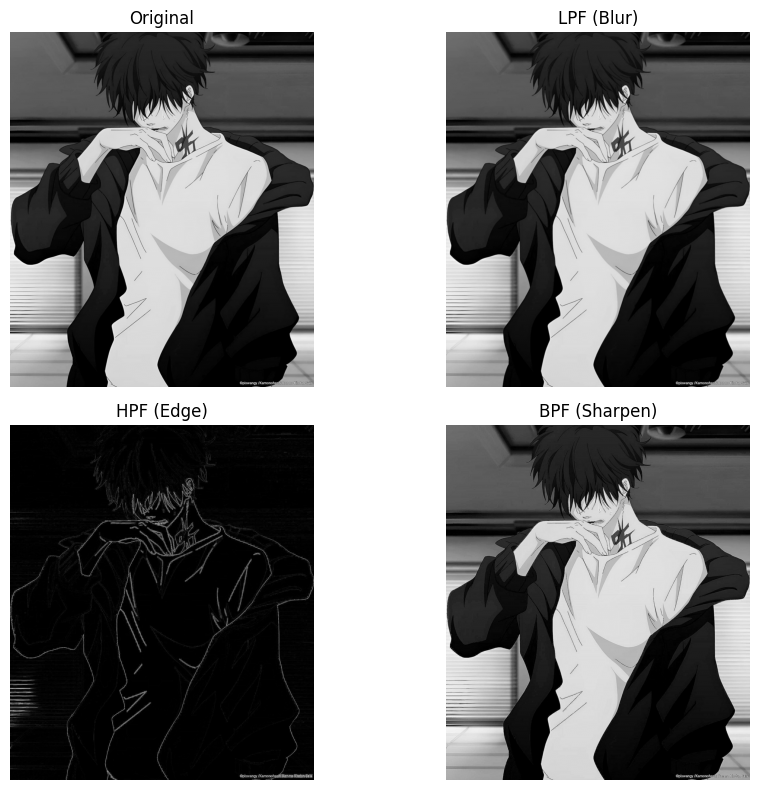

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload gambar
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Baca grayscale
img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# =========================
# Kernel
# =========================
lpf = (1/9) * np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.float32)

hpf = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
], dtype=np.float32)

bpf = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
], dtype=np.float32)

# =========================
# Konvolusi
# =========================
img_lpf = cv2.filter2D(img, -1, lpf)

img_hpf = cv2.filter2D(img, -1, hpf)
img_hpf = cv2.convertScaleAbs(img_hpf)  # biar edge keliatan

img_bpf = cv2.filter2D(img, -1, bpf)

# =========================
# Mean
# =========================
print("Mean Original :", np.mean(img))
print("Mean LPF      :", np.mean(img_lpf))
print("Mean HPF      :", np.mean(img_hpf))
print("Mean BPF      :", np.mean(img_bpf))

# =========================
# Tampilkan
# =========================
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_lpf, cmap='gray')
plt.title("LPF (Blur)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_hpf, cmap='gray')
plt.title("HPF (Edge)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_bpf, cmap='gray')
plt.title("BPF (Sharpen)")
plt.axis('off')

plt.tight_layout()
plt.show()